# 30b — Light-artifact diagnostics

**Part A (§1–§6)** — the WT *opto*-trial artifact in `uniform`: is WT's PSE shift under opto a
stimulus-independent side bias (light-delivery artifact → discard PSE/slope) or a criterion shift?

**Part B (§B1–§B3)** — the separate movement artifact on the dedicated **masking** sessions,
across all three distributions.

Model-free throughout: empirical P(choose B) by stimulus, opto vs the interleaved `opto_off`,
per animal.

- **Primary (§3–§4).** ΔP(B) vs stimulus. Flat & non-zero *including the saturated tails* ⇒
  additive offset = artifact. Peaked near the boundary, ~0 in the tails ⇒ criterion shift = real.
- **Secondary (§5).** SDT criterion `c` / `d′` — conventional language only; `c` carries the
  same horizontal-shift ambiguity as the psychometric μ, so it is **not** the discriminator.
- **Control (§6).** Is recency (the history channel) spared?

n=4 WT floors the genotype contrast — the *shape* and sign-consistency are the evidence, not a
p-value.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
from shared_setup import *

from analysis.opto import (
    compute_choice_by_stimulus, compute_side_bias, compute_sdt, extract_opto_estimates,
)
from behav_utils.analysis import paired_diff, rank_test, min_achievable_p
from plotting.opto import plot_choice_by_stimulus, plot_delta_by_stimulus, plot_delta_swarm

PHASE = 'uniform'
experiment, info = load_data()
geno, groups = gather_genotypes(experiment)
het, wt = groups.get('het', []), groups.get('wt', [])
opto_ids = het + wt
if not het or not wt:
    raise RuntimeError("No HET/WT genotypes on loaded animals (gather_genotypes reads .genotype).")
print(f"loaded ({info['mode']}): het={het} wt={wt}")

Loaded snapshot: 22 animals, 1267 sessions (exported 2026-07-20)
loaded (snapshot): het=['SS01', 'SS02', 'SS04', 'SS05', 'SS06', 'SS07', 'SS08', 'SS09', 'SS10', 'SS11', 'SS13', 'SS15', 'SS16', 'SS19', 'SS21', 'SS22', 'SS23'] wt=['SS14', 'SS17', 'SS18', 'SS20']


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:142: UserWarning: 1 animal(s) without genotype metadata: SS12. Add animal_metadata.json (genotype field) or they stay 'unknown'.
  warnings.warn(


In [2]:
# One model-free pass: empirical P(B) by stimulus + hit/FA, opto vs opto_off, per animal.
cbs = compute_choice_by_stimulus(experiment, phase=PHASE, animals=opto_ids)
present = sorted(cbs['binned']['animal'].unique())
print("conditions:", cbs['trial_types'], "| animals with data:", present)

conditions: ('opto', 'opto_off') | animals with data: ['SS14', 'SS15', 'SS16', 'SS17', 'SS18', 'SS20', 'SS21', 'SS22', 'SS23']


## §2 · Empirical psychometric, opto vs opto_off — per WT animal
Raw binned P(choose B), no fitted curve. Watch the **tails**: an additive offset lifts them, a
criterion shift leaves them pinned at floor/ceiling.

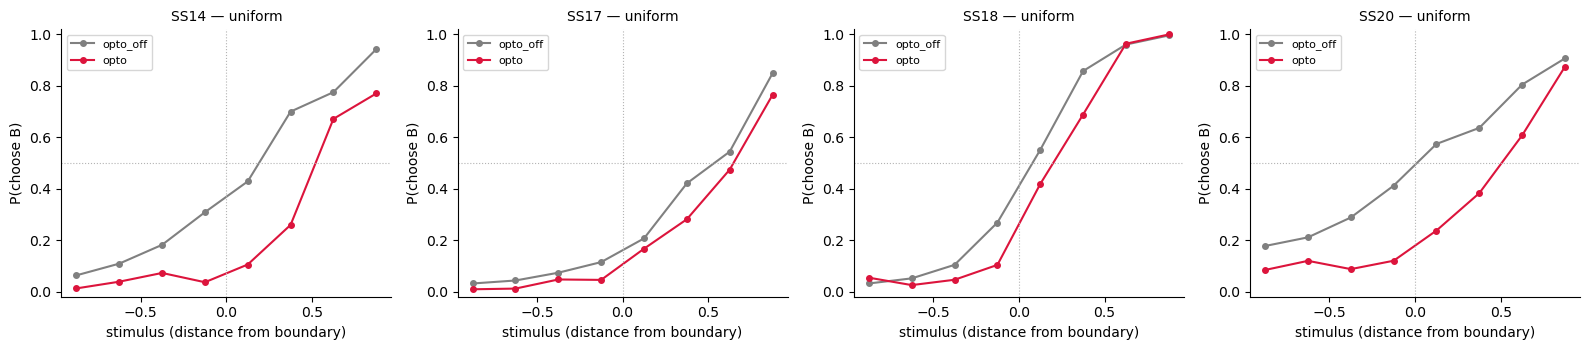

In [3]:
wt_present = [a for a in wt if a in set(cbs['binned']['animal'])]
ncol = min(4, len(wt_present)) or 1
fig, axes = plt.subplots(1, ncol, figsize=(4 * ncol, 3.6), squeeze=False)
for ax, aid in zip(axes[0], wt_present):
    plot_choice_by_stimulus(cbs, aid, ax=ax)
fig.tight_layout()

## §3 · ΔP(B) vs stimulus — the discriminator
opto − opto_off at each stimulus level, one thin line per animal, mean in red.
**Flat & non-zero (incl. tails) ⇒ additive offset (light artifact). Peaked near 0, ~0 in the
tails ⇒ criterion/boundary shift (real).**

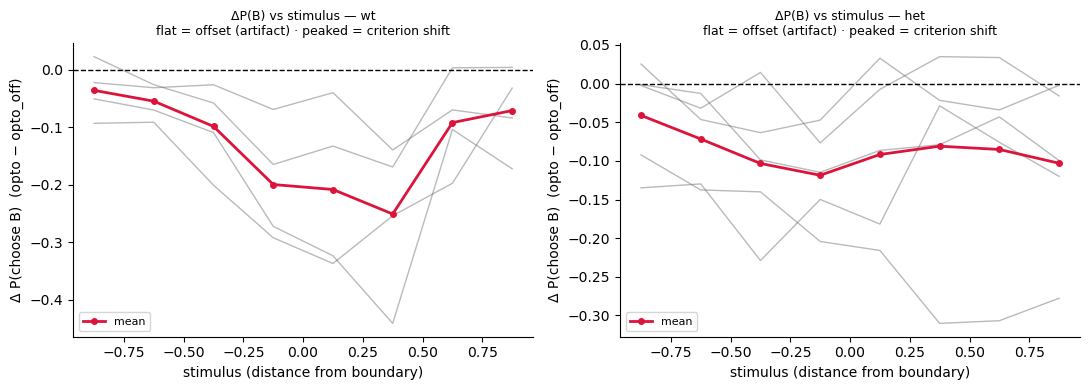

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_delta_by_stimulus(cbs, ax=axes[0], genotype='wt')
plot_delta_by_stimulus(cbs, ax=axes[1], genotype='het')
fig.tight_layout()

## §4 · Side-bias scalars (primary)
`net_bias` = overall ΔP(B); `tail_delta` = mean ΔP(B) in the saturated bins; `boundary_delta` =
near-threshold bins. **Artifact ⇒ tail_delta and boundary_delta both non-zero (flat).
Criterion shift ⇒ boundary_delta only, tail_delta ≈ 0.** `net_bias` het vs wt tests a lateralised
bias, reported with its achievable-p floor (n=4 WT ⇒ floor ≈ 0.057).

,animal,genotype,net_bias,tail_delta,boundary_delta
0,SS14,wt,-0.201,-0.099,-0.286
1,SS15,het,-0.023,-0.004,-0.009
2,SS16,het,-0.144,-0.115,-0.147
3,SS17,wt,-0.052,-0.052,-0.069
4,SS18,wt,-0.056,0.001,-0.131
5,SS20,wt,-0.179,-0.104,-0.271
6,SS21,het,-0.008,-0.014,-0.025
7,SS22,het,-0.214,-0.204,-0.218
8,SS23,het,-0.052,-0.039,-0.095


net_bias het vs wt: U=13.0  p=0.556  (min achievable p=0.0159, n_het=5 n_wt=4)


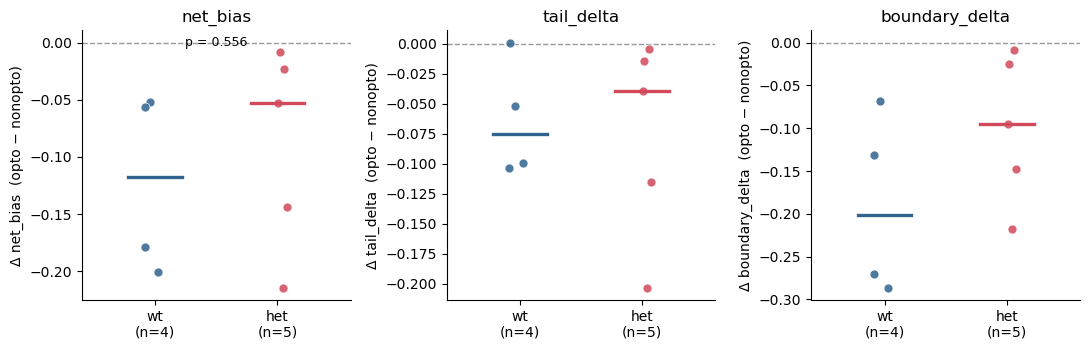

In [5]:
sb = compute_side_bias(cbs)
display(sb.round(3))

h = sb[sb.genotype == 'het']['net_bias'].dropna().to_numpy()
w = sb[sb.genotype == 'wt']['net_bias'].dropna().to_numpy()
res = rank_test(h, w, paired=False)
print(f"net_bias het vs wt: U={res['statistic']:.1f}  p={res['p']:.3g}  "
      f"(min achievable p={min_achievable_p('rank_sum', n1=len(h), n2=len(w)):.3g}, "
      f"n_het={len(h)} n_wt={len(w)})")

long = sb.melt(id_vars=['animal', 'genotype'],
               value_vars=['net_bias', 'tail_delta', 'boundary_delta'],
               var_name='stat', value_name='delta')
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, st in zip(axes, ['net_bias', 'tail_delta', 'boundary_delta']):
    plot_delta_swarm(long, st, ax=ax, p_value=res['p'] if st == 'net_bias' else None)
fig.tight_layout()

## §5 · Signal-detection (secondary, descriptive)
Criterion `c` and sensitivity `d′` per condition (empirical hit/FA, log-linear correction).
**Not the discriminator** — `c` absorbs both a motor offset and a boundary move, the same
ambiguity as PSE. Reported as conventional language beside §3–§4. `saturated` flags animals whose
raw hit/fa hit 0/1 (`d′` imprecise there). Equal-variance Gaussian assumed.

,animal,genotype,dprime_opto,c_opto,dprime_opto_off,c_opto_off,d_dprime,d_c,saturated
0,SS14,wt,1.597,0.944,1.568,0.194,0.029,0.750,False
1,SS15,het,2.403,0.418,2.294,0.284,0.108,0.134,False
2,SS16,het,1.391,0.462,1.079,0.028,0.312,0.435,False
3,SS17,wt,1.735,1.040,1.558,0.739,0.176,0.301,False
4,SS18,wt,2.338,0.405,2.252,0.122,0.086,0.282,False
5,SS20,wt,1.401,0.565,1.251,-0.006,0.150,0.570,False
6,SS21,het,2.173,-0.020,2.010,-0.062,0.163,0.043,False
7,SS22,het,1.030,0.766,1.172,0.115,-0.142,0.651,False
8,SS23,het,1.790,0.584,1.688,0.287,0.102,0.297,False


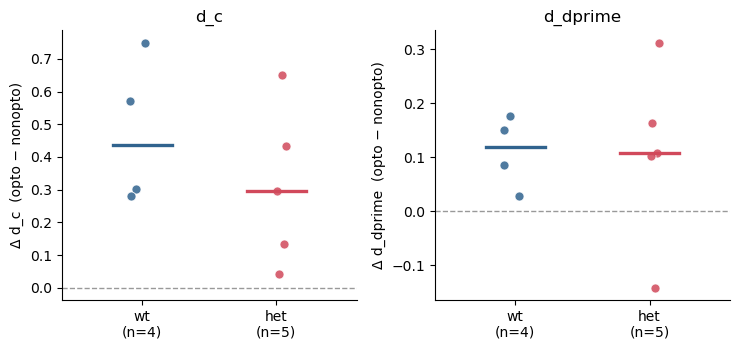

In [6]:
sdt = compute_sdt(cbs)
display(sdt.round(3))
if sdt['saturated'].any():
    print("saturated (d′ imprecise):", sorted(sdt[sdt.saturated]['animal']))

long_sdt = sdt.dropna(subset=['d_c']).melt(
    id_vars=['animal', 'genotype'], value_vars=['d_c', 'd_dprime'],
    var_name='stat', value_name='delta')
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))
for ax, st in zip(axes, ['d_c', 'd_dprime']):
    plot_delta_swarm(long_sdt, st, ax=ax)
fig.tight_layout()

## §6 · Is recency spared? (history-channel control)
The payoff. A pure offset artifact should not change recency (trial-to-trial updating). If PSE
shifts but recency doesn't, the history stats in `30`/`31` stand and only PSE/slope are binned.

recency Δ het vs wt: U=15.0  p=0.286  (min achievable p=0.0159)


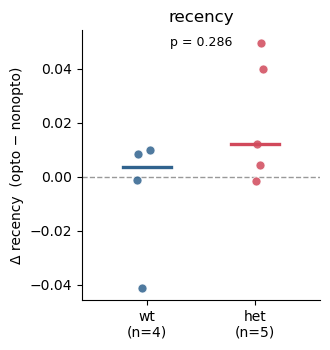

In [7]:
rec = extract_opto_estimates(experiment, phases=PHASE, stats=['recency'],
                             trial_types=('opto', 'opto_off'), animals=opto_ids)
drec = paired_diff(rec, by='trial_type', a='opto', b='opto_off')   # opto − opto_off per animal

hr = drec[drec.genotype == 'het']['delta'].dropna().to_numpy()
wr = drec[drec.genotype == 'wt']['delta'].dropna().to_numpy()
rr = rank_test(hr, wr, paired=False)
print(f"recency Δ het vs wt: U={rr['statistic']:.1f}  p={rr['p']:.3g}  "
      f"(min achievable p={min_achievable_p('rank_sum', n1=len(hr), n2=len(wr)):.3g})")
fig, ax = plt.subplots(figsize=(3.4, 3.6))
plot_delta_swarm(drec, 'recency', ax=ax, p_value=rr['p'])
fig.tight_layout()

**Reading it.** Discriminator is §3–§4: if ΔP(B) is flat and non-zero into the tails and
`tail_delta`≈`boundary_delta`≈`net_bias` with a consistent sign across WT, the WT effect is a
light-delivery side bias → **bin PSE/slope from `30`/`31`**. If instead ΔP(B) peaks at the
boundary with `tail_delta`≈0, it is a criterion shift and the interpretation is different. §5 is
description only. §6 decides the history stats: recency Δ ≈ 0 (both genotypes) ⇒ the history
channel is clean and the `30`/`31` history-stat conclusions hold. All descriptive at this n.

---
# Part B — Masking-session movement artifact (all distributions)

Part A used the WT *opto*-trial artifact. This part asks a separate question on the dedicated
**masking sessions**: the laser is at power 0, but the galvo still moves and the masking light
fires on the interleaved ~30 % (`Zapit=True` → `opto`); the rest are `opto_off`. Does that
movement / masking light itself bias choice?

Power is 0 for **both** genotypes, so there is no inhibition to isolate — the contrast is the
artifact itself. The primary test is each animal's Δ (`opto − opto_off`) pooled across **all**
animals (is there any movement effect); het-vs-wt is only an equivalence check.

**Caveat (carries from Part A).** The offset-vs-criterion discriminator needs the stimulus tails
sampled, which only `uniform` does. For `hard_a` / `hard_b`, read `net_bias`, `boundary_delta`
and `recency` only — the `tail_delta` / SDT-rate tests are unreliable there.

In [8]:
# opto (Zapit, power 0 — galvo moved) vs opto_off, on masking sessions, per distribution.
MASK_DISTS = ['uniform', 'hard_a', 'hard_b']
cbs_mask = {d: compute_choice_by_stimulus(experiment, phase=d, session_type='masking',
                                          animals=opto_ids)
            for d in MASK_DISTS}
for d in MASK_DISTS:
    present = sorted(cbs_mask[d]['binned']['animal'].unique())
    print(f"{d:8s} masking: {len(present):2d} animal(s) with data -> {present}")

uniform  masking:  8 animal(s) with data -> ['SS14', 'SS15', 'SS16', 'SS17', 'SS18', 'SS21', 'SS22', 'SS23']
hard_a   masking:  7 animal(s) with data -> ['SS14', 'SS15', 'SS16', 'SS18', 'SS20', 'SS21', 'SS23']
hard_b   masking:  7 animal(s) with data -> ['SS14', 'SS15', 'SS16', 'SS18', 'SS20', 'SS21', 'SS23']


## §B1 · Movement effect — side-bias scalars, per distribution

`net_bias` = overall ΔP(B) (`opto − opto_off`). Tested two ways: against zero across **all**
animals (is there any movement effect), and het-vs-wt (equivalence — expect ≈ null, both
power-0). `tail_delta` / `boundary_delta` are shown but trustworthy for `uniform` only.

In [9]:
rows = []
for d in MASK_DISTS:
    sb = compute_side_bias(cbs_mask[d])
    nbz = sb['net_bias'].dropna().to_numpy()
    res0 = rank_test(nbz, np.zeros_like(nbz), paired=True) if len(nbz) >= 3 else {'statistic': np.nan, 'p': np.nan}
    h = sb[sb.genotype == 'het']['net_bias'].dropna().to_numpy()
    w = sb[sb.genotype == 'wt']['net_bias'].dropna().to_numpy()
    resg = rank_test(h, w, paired=False) if len(h) and len(w) else {'statistic': np.nan, 'p': np.nan}
    rows.append(dict(dist=d, n=len(nbz),
                     median_net_bias=float(np.median(nbz)) if len(nbz) else np.nan,
                     median_tail=float(np.nanmedian(sb['tail_delta'])) if sb['tail_delta'].notna().any() else np.nan,
                     median_boundary=float(np.nanmedian(sb['boundary_delta'])) if sb['boundary_delta'].notna().any() else np.nan,
                     p_vs_zero=res0['p'], p_het_vs_wt=resg['p'],
                     min_p_vs_zero=min_achievable_p('signed_rank', n=int((nbz != 0).sum())) if len(nbz) else np.nan))
mask_bias = pd.DataFrame(rows)
display(mask_bias.round(4))

,dist,n,median_net_bias,median_tail,median_boundary,p_vs_zero,p_het_vs_wt,min_p_vs_zero
0,uniform,8,0.0348,0.0174,0.0264,0.0781,1.0000,0.0078
1,hard_a,7,-0.0010,-0.0118,0.0236,0.8125,0.2286,0.0156
2,hard_b,7,0.0053,-0.0069,0.0172,0.5781,0.8571,0.0156


## §B2 · ΔP(B) vs stimulus (pooled across animals), per distribution

Flat & non-zero incl. tails ⇒ additive offset (movement artifact); peaked near the boundary,
≈0 in the tails ⇒ criterion shift. Only `uniform` samples the tails — the `hard` panels are
boundary-only and cannot separate offset from criterion.

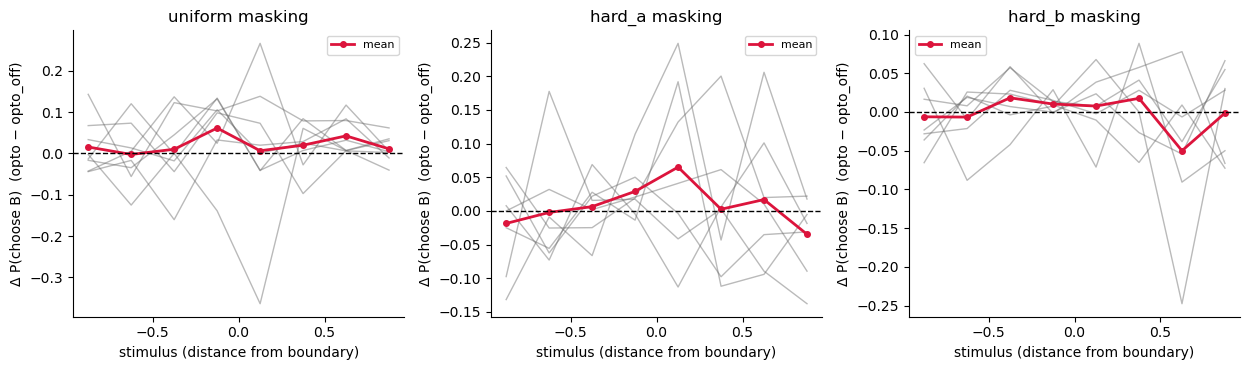

In [10]:
have = [d for d in MASK_DISTS if not cbs_mask[d]['binned'].empty]
if not have:
    print("no masking sessions in any distribution")
else:
    fig, axes = plt.subplots(1, len(have), figsize=(4.2 * len(have), 3.8), squeeze=False)
    for ax, d in zip(axes[0], have):
        plot_delta_by_stimulus(cbs_mask[d], ax=ax)      # genotype=None -> pooled across all animals
        ax.set_title(f"{d} masking")
    fig.tight_layout()

## §B3 · Is recency spared under masking? (history-channel control)

Same logic as §6: a pure movement / offset artifact should not move recency. Δ recency
(`opto − opto_off`), tested against zero across all animals, per distribution.

In [11]:
rows = []
for d in MASK_DISTS:
    rec = extract_opto_estimates(experiment, phases=d, stats=['recency'],
                                 trial_types=('opto', 'opto_off'), session_type='masking',
                                 animals=opto_ids)
    if rec.empty:
        rows.append(dict(dist=d, n=0, median_d_recency=np.nan, p_vs_zero=np.nan))
        continue
    dr = paired_diff(rec, by='trial_type', a='opto', b='opto_off')
    dd = dr['delta'].dropna().to_numpy()
    res0 = rank_test(dd, np.zeros_like(dd), paired=True) if len(dd) >= 3 else {'statistic': np.nan, 'p': np.nan}
    rows.append(dict(dist=d, n=len(dd),
                     median_d_recency=float(np.median(dd)) if len(dd) else np.nan,
                     p_vs_zero=res0['p']))
display(pd.DataFrame(rows).round(4))

,dist,n,median_d_recency,p_vs_zero
0,uniform,8,-0.0030,1.000
1,hard_a,7,-0.0235,1.000
2,hard_b,7,0.0048,0.375


**Reading Part B.** `net_bias` significantly ≠ 0 with a consistent sign ⇒ the galvo movement /
masking light shifts choice — a nuisance to control for in the opto sessions. In `uniform`, if
`tail_delta ≈ net_bias` (flat Δ into the tails) it is an additive offset; if `tail_delta ≈ 0`
with `boundary_delta ≠ 0` it is criterion-like. `hard_a` / `hard_b` give the movement-effect
magnitude (`net_bias`) but not the offset/criterion split. Δ recency ≈ 0 ⇒ movement leaves the
history channel clean. All descriptive at this n; het-vs-wt is an equivalence check, not the test.